In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.append("../../src/")


import scipy.stats as stats
from tqdm import tqdm
from baseline_network import BaselineNetwork

In [3]:
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'

In [4]:
seed = 100

/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:679: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
100%|██████████| 840/840 [00:45<00:00, 18.37it/s]


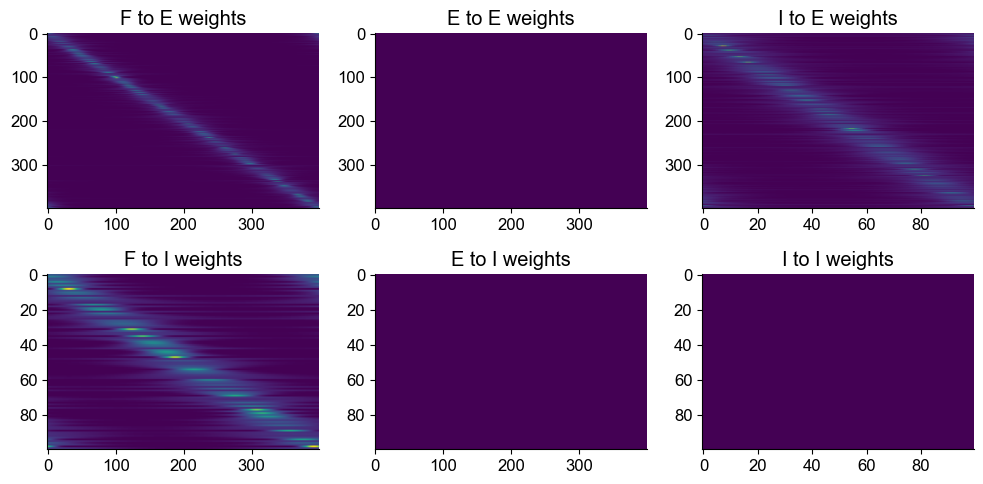

In [5]:
net_time_varying = BaselineNetwork(inh_type="co-tuned", E_to_E="off", E_to_I="off", I_to_I="off",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=seed, 
                      inh_time_varying=True,
                      if_pre_run=True, n_pre_run_stimuli=300,
                      inh_scale=0.3)
net_time_varying.run()


100%|██████████| 840/840 [00:45<00:00, 18.44it/s]


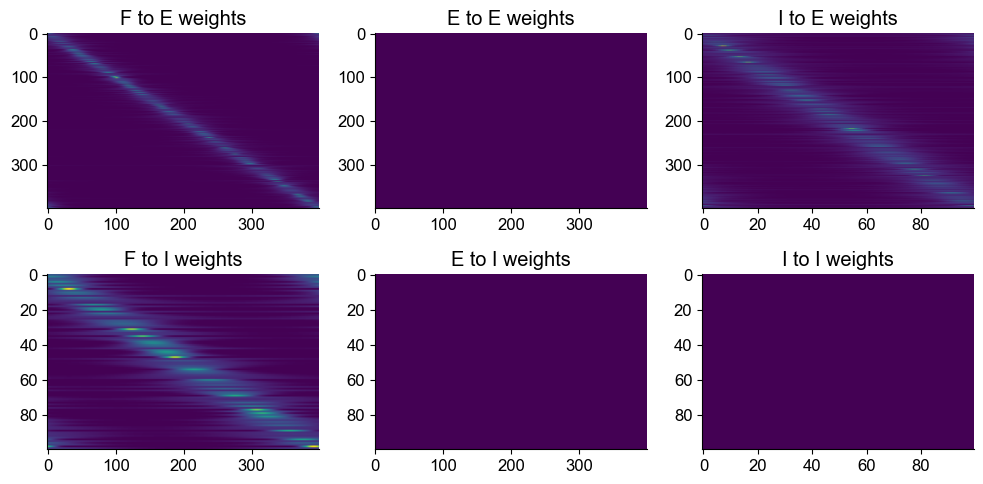

In [6]:

net_baseline = BaselineNetwork(inh_type="co-tuned", E_to_E="off", E_to_I="off", I_to_I="off",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=seed, 
                      inh_time_varying=False,
                      if_pre_run=True, n_pre_run_stimuli=300,
                      inh_scale=0.3)
net_baseline.run()

In [7]:
drift_mag_time_varying, drift_rate_time_varying, convergence_time_varying = net_time_varying.get_drift_metrics()

drift_mag_baseline, drift_rate_baseline, convergence_baseline = net_baseline.get_drift_metrics()

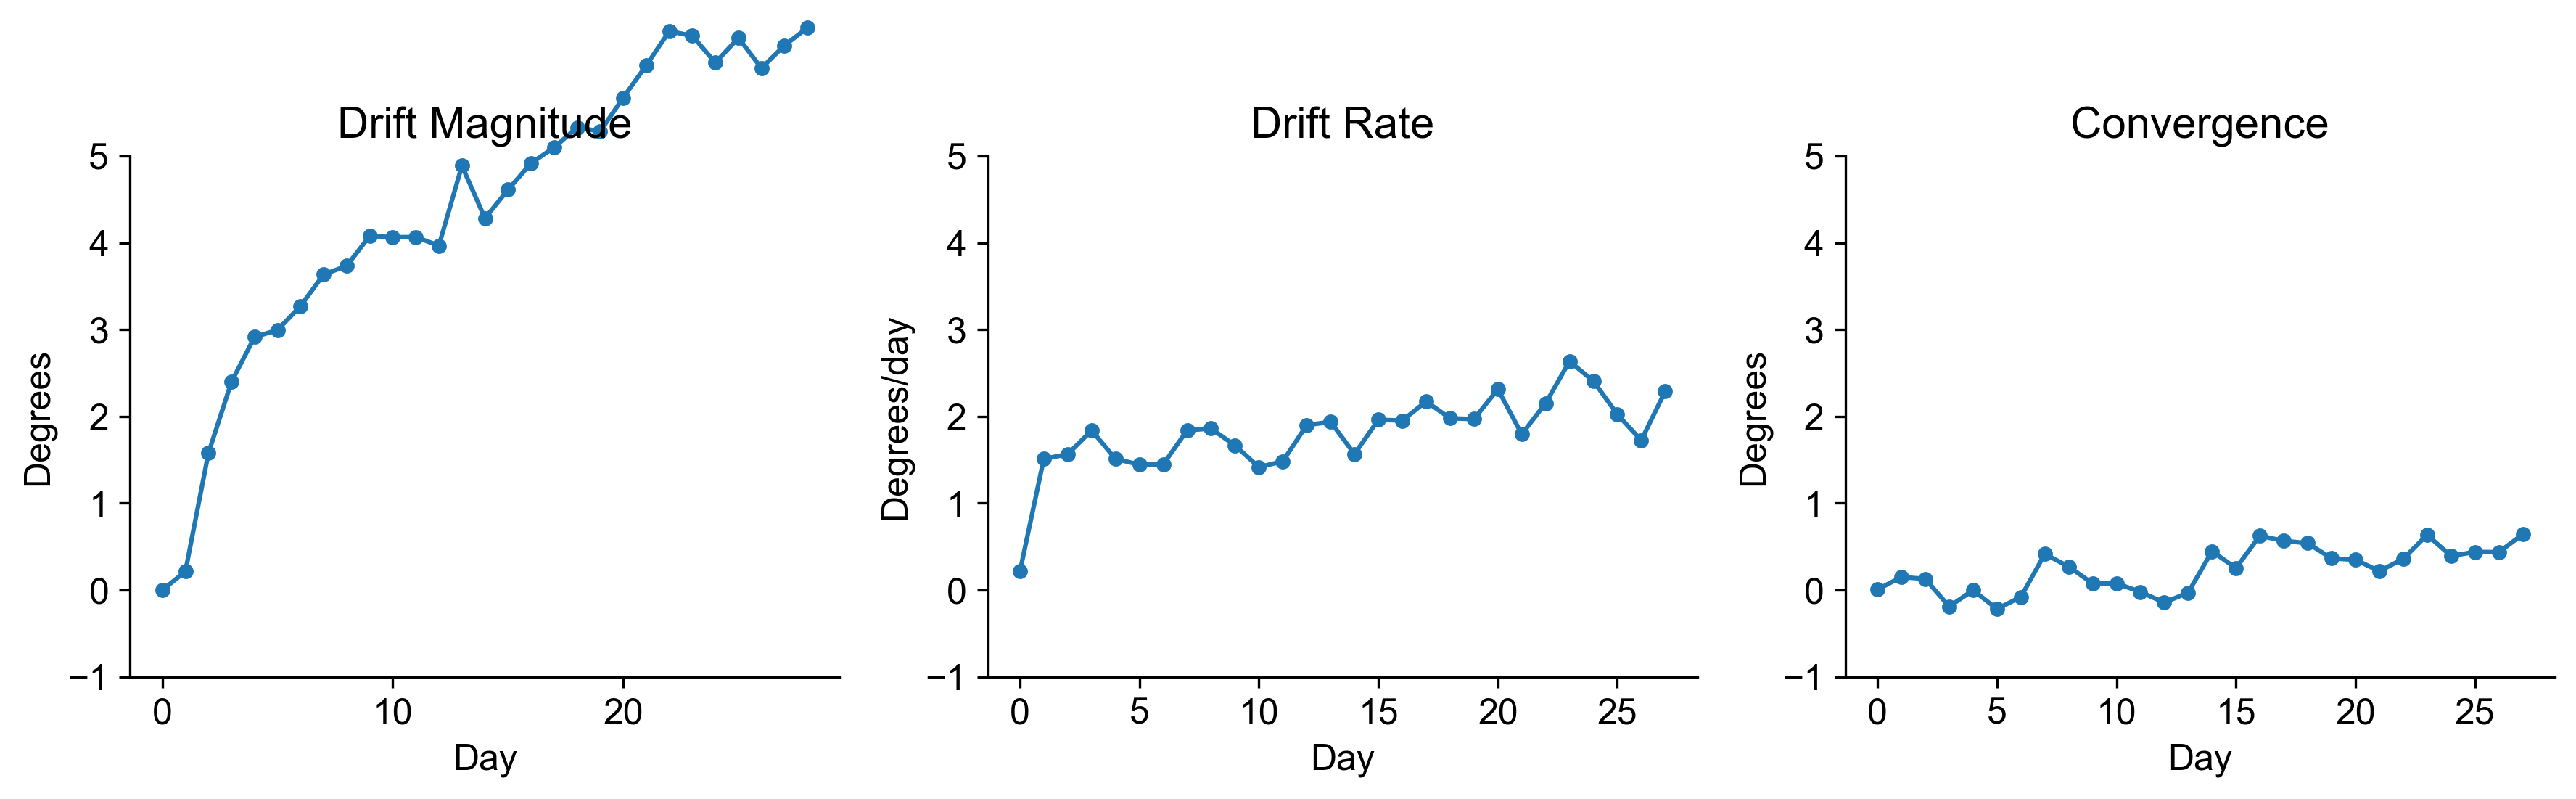

In [8]:
eo = 2

fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=300)

# drift_mag_mean = np.nanmean(drift_mag, axis=1)
# drift_mag_std = np.nanstd(drift_mag, axis=1)/np.sqrt(drift_mag.shape[1])
axs[0].plot(np.mean(drift_mag_time_varying, axis=1), marker='o', ms=4, clip_on=False)
# axs[0].plot(np.mean(drift_mag_baseline, axis=1), marker='o', ms=4, clip_on=False)
# axs[0].fill_between(range(len(drift_mag_mean)), drift_mag_mean - drift_mag_std, drift_mag_mean + drift_mag_std, alpha=0.2)
axs[0].set_title("Drift Magnitude")
axs[0].set_xlabel("Day")
axs[0].set_ylabel("Degrees")
axs[0].set_ylim([-1, 5])

# drift_rate_mean = np.nanmean(drift_rate, axis=1)
# drift_rate_std = np.nanstd(drift_rate, axis=1)/np.sqrt(drift_rate.shape[1])
axs[1].plot(np.mean(drift_rate_time_varying, axis=1), marker='o', ms=4, clip_on=False)
# axs[1].plot(np.mean(drift_rate_baseline, axis=1), marker='o', ms=4, clip_on=False)
# axs[1].fill_between(range(len(drift_rate_mean)), drift_rate_mean - drift_rate_std, drift_rate_mean + drift_rate_std, alpha=0.2)
axs[1].set_title("Drift Rate")
axs[1].set_xlabel("Day")
axs[1].set_ylabel("Degrees/day")
axs[1].set_ylim([-1, 5])

# convergence_mean = np.nanmean(convergence, axis=1)
# convergence_std = np.nanstd(convergence, axis=1)/np.sqrt(convergence.shape[1])
axs[2].plot(np.mean(convergence_time_varying, axis=1), marker='o', ms=4, clip_on=False)
# axs[2].plot(np.mean(convergence_baseline, axis=1), marker='o', ms=4, clip_on=False)
# axs[2].fill_between(range(len(convergence_mean)), convergence_mean - convergence_std, convergence_mean + convergence_std, alpha=0.2)
axs[2].set_title("Convergence")
axs[2].set_xlabel("Day")
axs[2].set_ylabel("Degrees")
axs[2].set_ylim([-1, 5])


fig.tight_layout()
# if savefig:
#     fig.savefig(self.save_location+"drift_metrics.png", dpi=300)
# fig.show()